In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [26]:
# Import libraries
import pandas as pd
import pickle
import sys; sys.path.insert(0, '..')

from src.features_prep import cats_cv_target_encode, num_mice_impute
from src.features_selection import run_boruta
from src.mixed_matrix import build_mixed_correlation, plot_matrix
from src.cluster_analysis import cluster_features, shap_pilot_model, select_representative, plot_dendrogram
from src.model_builder import run_optuna

In [3]:
# Import longlist factors
longList = pd.read_csv(
    '../data/raw/longlistFactor.csv'
)

# Define features types
CAT_COLS = longList.query(
    "data_type == 'Categorical'"
)['factor'].tolist()

NUM_COLS = longList.query(
    "data_type == 'Continuous'"
)['factor'].tolist()

# All features
ALL_COLS = CAT_COLS + NUM_COLS

# Features to group
ALL_GROUP = longList.groupby('factor_type')['factor'].apply(list).to_dict()

In [4]:
# Import data
df = pd.read_parquet(
    '../data/processed/train_data.parquet',
    engine = 'pyarrow'
)

# Define features and target
X_train = df[ALL_COLS]
y_train = df['ever_default_6']

del df #Remove initial data

In [5]:
# Convert data types
X_train[CAT_COLS] = X_train[CAT_COLS].astype(object)

In [6]:
# Features transformer (Encoding, imputation)
X_train_enc = cats_cv_target_encode(X_train, y_train, cols_types = CAT_COLS)
X_train_enc = num_mice_impute(X_train_enc, cols_types = NUM_COLS)

=== Processing ===
[CV Target Encoding]
Total features: 370
Total categorical features: 97
=== Processing ===
[MICE for missing values]
Total features: 370
Total numerical features: 273
Total missing values in numerical features: 2
Total missing values in numerical features after imputation: 0


In [7]:
# Features selection
selected_features, features_imp = run_boruta(X_train_enc, y_train, cat_cols = None, pass_threshold = 0.7)

=== Processing ===
[Features selection by LightGBM]
Total features: 370
Total shadow features: 740
Total selected features: 27
Cut-off selected threshold: 3038.36


In [8]:
# Seperated by features types --> Numerical features
sel_num = [c for c in selected_features if c in NUM_COLS]
print(f"=== Result ===\nTotal numerical features: {len(sel_num)}\nDetails:")
for s in sel_num:
    print(f"    {s}")

=== Result ===
Total numerical features: 20
Details:
    avg_bal_9
    avg_bal_12_to_fin
    avg_bal_9_to_fin
    max_bal_9_to_fin
    bal_to_fin
    avg_bal_9_to_avg_bal_12
    avg_bal_12_to_min_bal_12
    avg_due_9_to_fin
    min_due_9_to_fin
    due_to_fin
    due
    max_ovd_6_to_fin
    ovd_to_fin
    avg_pay_12
    max_pay_12
    max_pay_3
    min_pay_12
    min_pay_6
    avg_pay_12_to_due
    avg_pay_9_to_due


In [9]:
# Seperated by features types --> Categorical features
sel_cat = [c for c in selected_features if c in CAT_COLS]
print(f"=== Result ===\nTotal numerical features: {len(sel_cat)}\nDetails:")
for s in sel_cat:
    print(f"    {s}")

=== Result ===
Total numerical features: 7
Details:
    n_fully_pay_9
    del
    del1
    max_del_12
    max_del_9
    max_del_6
    max_del_3


In [10]:
# Create the correlation matrix for mixed data
corr_matrix = build_mixed_correlation(X_train[selected_features], sel_num, sel_cat)

=== Processing ===
[Correlation matrix for mixed data]
Correlation matrix shape: (27, 27)


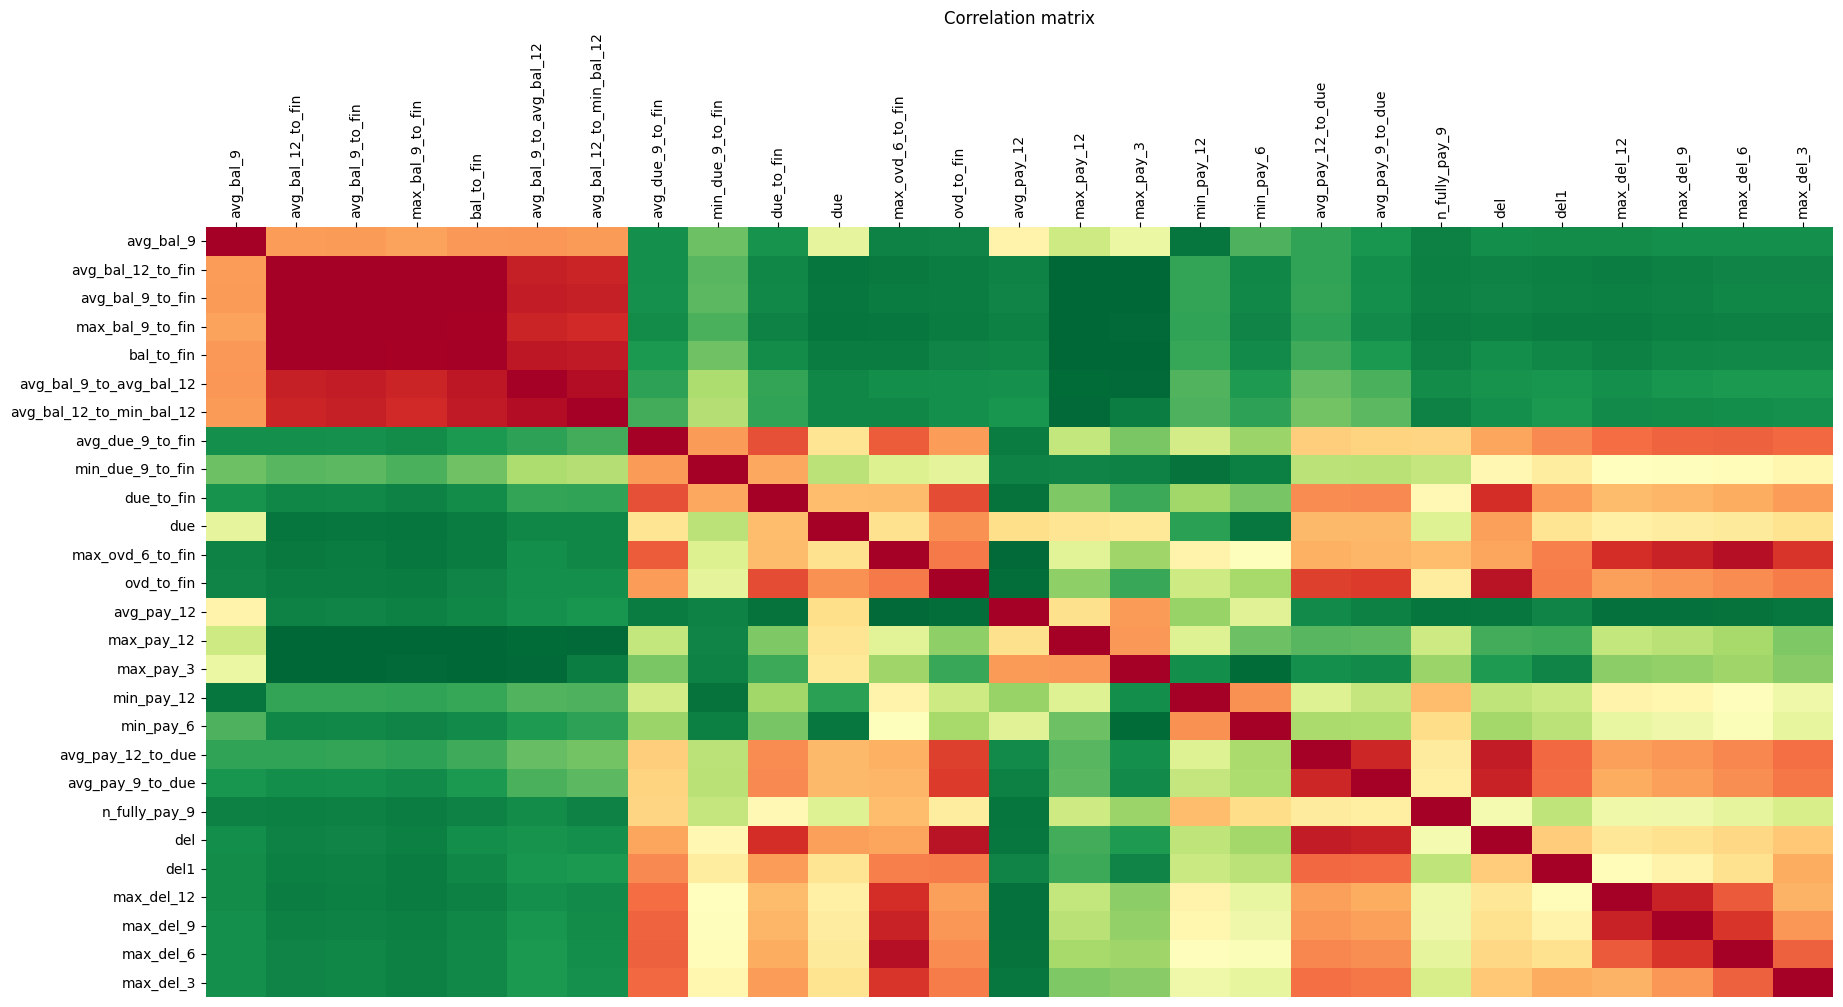

In [11]:
# Plot
plot_matrix(corr_matrix)

In [12]:
# Cluster analysis
linkage_matrix, cluster_df = cluster_features(corr_matrix, distance_threshold = 0.4)

=== Processing ===
[Cluster analysis]
Cluster results (Threshold: 40%)
    Cluster 1: ['avg_bal_9', 'avg_bal_12_to_fin', 'avg_bal_9_to_fin', 'max_bal_9_to_fin', 'bal_to_fin', 'avg_bal_9_to_avg_bal_12', 'avg_bal_12_to_min_bal_12']
    Cluster 2: ['max_pay_12', 'avg_pay_12', 'max_pay_3']
    Cluster 3: ['min_pay_6', 'min_pay_12', 'n_fully_pay_9']
    Cluster 4: ['avg_pay_12_to_due', 'ovd_to_fin', 'due', 'avg_pay_9_to_due', 'del']
    Cluster 5: ['max_del_12', 'max_ovd_6_to_fin', 'max_del_6', 'max_del_9']
    Cluster 6: ['avg_due_9_to_fin', 'due_to_fin', 'max_del_3', 'del1']
    Cluster 7: ['min_due_9_to_fin']


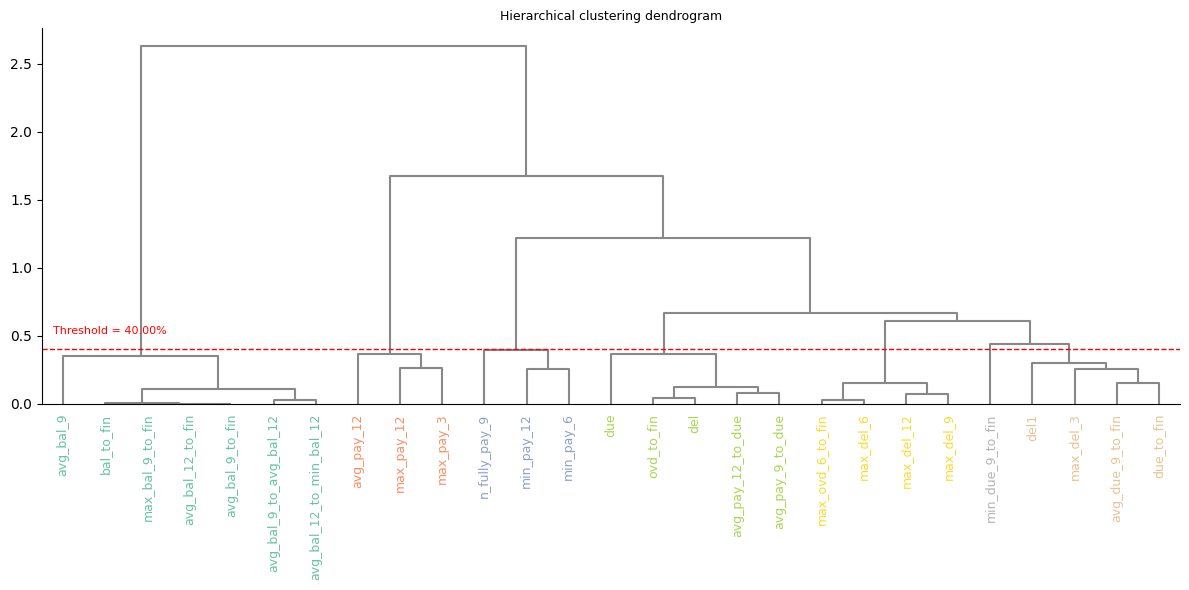

In [13]:
# Plot dendrogram
plot_dendrogram(corr_matrix, cluster_df, linkage_matrix, 0.4)

In [14]:
# Pilot model
shap_importance = shap_pilot_model(X_train, y_train, features = selected_features, cats_cols = sel_cat)

=== Processing ===
[SHAP Importance]
0:	total: 283ms	remaining: 2m 21s
100:	total: 16.5s	remaining: 1m 5s
200:	total: 33.3s	remaining: 49.6s
300:	total: 49.6s	remaining: 32.8s
400:	total: 1m 5s	remaining: 16.1s
499:	total: 1m 22s	remaining: 0us
Average SHAP Importance: 0.09


In [15]:
# Features selection from cluster
final_features = select_representative(cluster_df, shap_importance, ALL_GROUP, n_per_cluster = 1)

=== Result ===
Cluster selection
    Cluster 1
        [✓] Select: ['avg_bal_12_to_min_bal_12']
            [✗] Dropped: ['avg_bal_9', 'avg_bal_12_to_fin', 'avg_bal_9_to_fin', 'max_bal_9_to_fin', 'bal_to_fin', 'avg_bal_9_to_avg_bal_12']
    Cluster 2
        [✓] Select: ['avg_pay_12']
            [✗] Dropped: ['max_pay_12', 'max_pay_3']
    Cluster 3
        [✓] Select: ['min_pay_6']
            [✗] Dropped: ['min_pay_12', 'n_fully_pay_9']
    Cluster 4
        [✓] Select: ['avg_pay_9_to_due']
            [✗] Dropped: ['avg_pay_12_to_due', 'ovd_to_fin', 'due', 'del']
    Cluster 5
        [✓] Select: ['max_ovd_6_to_fin']
            [✗] Dropped: ['max_del_12', 'max_del_6', 'max_del_9']
    Cluster 6
        [✓] Select: ['max_del_3']
            [✗] Dropped: ['avg_due_9_to_fin', 'due_to_fin', 'del1']
    Cluster 7
        [✓] Select: 'min_due_9_to_fin' (Only 1 contained)


In [ ]:
# Final selected features
# ============================================================================================================= #
# 1. 'avg_bal_12_to_min_bal_12' is Average balance over the last 12 months to minimum balance in last 12 months #
# 2. 'min_pay_6' is Minimum repayment amount in past 6 months                                                   #
# 3. 'avg_pay_9_to_due' is Average of repayment in past 9 months to due amount                                  #
# 4. 'max_ovd_6_to_fin' is Maximum overdue amount in the past 6 months to financed amount                       #
# 5. 'max_del_3' is Maximum delinquency in past 3 months                                                        #
# 6. 'min_due_9_to_fin' is Minimum due amount in the past 9 months to financed amount                           #
# Note:                                                                                                         #
#   'avg_pay_12' is manually dropped because selecting 'min_pay_6' instead.                                     #
# ============================================================================================================= #
final_selcted = final_features.copy()
final_selcted.remove('avg_pay_12')

# Final dataset
X_train = X_train[final_selcted]
X_train.head(5)

,avg_bal_12_to_min_bal_12,min_pay_6,avg_pay_9_to_due,max_ovd_6_to_fin,max_del_3,min_due_9_to_fin
13970,1.093333,0.0,0.888889,0.020209,1.0,0.020209
13971,1.119266,0.0,1.006233,0.020209,1.0,0.020209
13972,1.123483,0.0,0.517637,0.020209,1.0,0.020209
13973,1.103856,0.0,0.895122,0.020209,1.0,0.020209
13974,1.130624,0.0,0.517637,0.020209,1.0,0.020209


In [ ]:
# Model training
best_model, study = run_optuna(
    X_train,
    y_train,
    n_trials = 20
)

[I 2026-04-19 22:21:10,367] A new study created in memory with name: no-name-a6f429cf-cd60-45e3-9aae-531f0fa3e749


=== Processing ===
[Model building]
Class distribution: Non-default = 279776, Default = 12225, Scale = 22.89


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-19 22:23:59,242] Trial 0 finished with value: 0.926570725486396 and parameters: {'iterations': 969, 'depth': 6, 'learning_rate': 0.017393825627343113, 'l2_leaf_reg': 11.862147911580719, 'min_data_in_leaf': 22, 'scale_pos_weight_multiplier': 1.562431325859375, 'random_strength': 3.5922613147980833, 'bagging_temperature': 0.918885811973944}. Best is trial 0 with value: 0.926570725486396.
[I 2026-04-19 22:26:11,333] Trial 1 finished with value: 0.9253499779126324 and parameters: {'iterations': 846, 'depth': 5, 'learning_rate': 0.010756402310676018, 'l2_leaf_reg': 3.605960985623309, 'min_data_in_leaf': 36, 'scale_pos_weight_multiplier': 1.1060755908854265, 'random_strength': 0.2091876575963542, 'bagging_temperature': 0.04520639198326548}. Best is trial 0 with value: 0.926570725486396.
[I 2026-04-19 22:27:44,834] Trial 2 finished with value: 0.928585428197964 and parameters: {'iterations': 554, 'depth': 6, 'learning_rate': 0.04369108667391148, 'l2_leaf_reg': 22.14457754158007, 'm

In [27]:
# Save model and study
best_model.save_model('../model/model.cbm')
with open('../model/model_study.pkl', 'wb') as f:
    pickle.dump(study, f)